In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal

In [3]:
class QuadState(TypedDict):
    a: float
    b: float
    c: float

    eqn: str
    discriminant: float
    result: str

In [4]:
def create_eqn(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    state['eqn'] = f"{a}x^2 + {b}x + {c} = 0"
    return {'eqn': state['eqn']}

def calculate_discriminant(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    state['discriminant'] = b**2 - 4*a*c
    return {'discriminant': state['discriminant']}

def real_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    d = state['discriminant']
    r1 = (-b+d**0.5)/(2*a)
    r2 = (-b-d**0.5)/(2*a)
    state['result'] = f"Real and Distinct Roots: {r1}, {r2}"
    return {'result': state['result']}

def equal_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    r = -b/(2*a)
    state['result'] = f"Real and Equal Roots: {r}"
    return {'result': state['result']}

def imaginary_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    d = state['discriminant']
    real_part = -b/(2*a)
    imag_part = (abs(d)**0.5)/(2*a)
    state['result'] = f"Imaginary Roots: {real_part} ± {imag_part}i"
    return {'result': state['result']}

In [9]:
def conditional_check(state: QuadState) -> Literal['real_roots', 'equal_roots', 'imaginary_roots']:
    d = state['discriminant']
    if d>0:
        return 'real_roots'
    elif d==0:
        return 'equal_roots'
    else:
        return 'imaginary_roots'

In [10]:
builder = StateGraph(QuadState)

builder.add_node('create_eqn', create_eqn)
builder.add_node('calculate_discriminant', calculate_discriminant)
builder.add_node('real_roots', real_roots)
builder.add_node('equal_roots', equal_roots)
builder.add_node('imaginary_roots', imaginary_roots)

builder.add_edge(START, 'create_eqn')
builder.add_edge('create_eqn', 'calculate_discriminant')
builder.add_conditional_edges('calculate_discriminant', conditional_check)
builder.add_edge('real_roots', END)
builder.add_edge('equal_roots', END)    
builder.add_edge('imaginary_roots', END)

workflow = builder.compile()

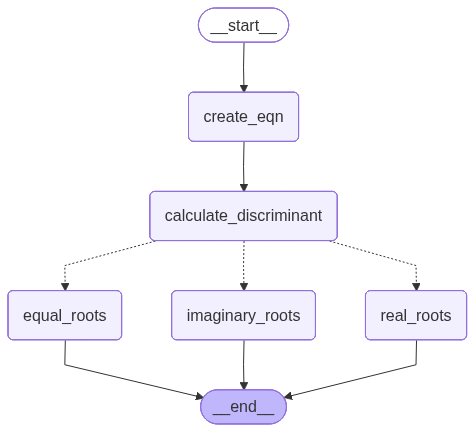

In [11]:
workflow

In [12]:
initial_state = QuadState(a=1, b=-3, c=2)
workflow.invoke(initial_state)

{'a': 1,
 'b': -3,
 'c': 2,
 'eqn': '1x^2 + -3x + 2 = 0',
 'discriminant': 1,
 'result': 'Real and Distinct Roots: 2.0, 1.0'}